In [7]:
import pandas as pd
import os 
import random
import subprocess

import dask.dataframe as dd
import seaborn as sns

import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
sign_results = [i for i in os.listdir('binom_reg/') if 'sign' in i]
sites = pd.Series(sign_results).str.split('_').str[-1].str.replace('.csv', '').astype(int).reset_index()

In [3]:
sites[0].values

array([ 2,  5, 24, 11, 32, 49, 10, 25, 57,  4, 46, 48, 45, 42, 13,  9, 53,
       54, 28, 43, 55,  6,  1, 52, 27, 12])

In [17]:
snps_names = pd.read_csv('../key_files/var_pos_grenenet.csv')

import pickle
with open('../key_files/blocks_snpsid_dict.pkl', 'rb') as f:
    dict_blocks = pickle.load(f)

reverse_mapping = {item: key for key, values in dict_blocks.items() for item in values}

#snps_names = snps_names[snps_names['total_alleles05filter_firstgen'].notna()].reset_index(drop=True)

In [22]:
snps_names

,id,pos,chrom,maf05filter,total_alleles05filter_firstgen,total_alleles05filter_lastgen
0,1_291,291,1,NaN,NaN,NaN
1,1_346,346,1,1_346,1_346,1_346
2,1_349,349,1,NaN,NaN,NaN
3,1_352,352,1,NaN,NaN,NaN
4,1_353,353,1,1_353,1_353,1_353
...,...,...,...,...,...,...
3235475,5_26975208,26975208,5,NaN,NaN,NaN
3235476,5_26975215,26975215,5,NaN,NaN,NaN
3235477,5_26975267,26975267,5,NaN,NaN,NaN
3235478,5_26975272,26975272,5,5_26975272,5_26975272,5_26975272


In [23]:
snps_names['total_alleles05filter_firstgen'].notna().sum()

1054574

In [30]:
snps_names['block'] = snps_names['id'].map(reverse_mapping)

In [32]:
snps_names['block'].nunique()

16917

In [36]:
snps_names[snps_names['maf05filter'].notna()]['block'].nunique()

16757

In [38]:
snps_names[snps_names['total_alleles05filter_lastgen'].notna()]['block'].nunique()

16665

In [26]:
dict_snps = pd.read_csv('../key_files/dict_snps.csv')

,id,pos,chrom,maf05filter,total_alleles05filter
0,1_291,291,1,NaN,NaN
1,1_346,346,1,1_346,1_346
2,1_349,349,1,NaN,NaN
3,1_352,352,1,NaN,NaN
4,1_353,353,1,1_353,NaN
...,...,...,...,...,...
3235475,5_26975208,26975208,5,NaN,NaN
3235476,5_26975215,26975215,5,NaN,NaN
3235477,5_26975267,26975267,5,NaN,NaN
3235478,5_26975272,26975272,5,5_26975272,5_26975272


In [25]:
snps_names['maf05filter'].notna().sum()

1147892

In [6]:
binomial_reg = pd.read_csv(f'binom_reg/site_{4}.csv')

In [7]:
binomial_reg

,slope,p_value,id
0,-0.369944,3.110702e-14,1_346
1,-0.584323,1.830801e-12,1_353
2,0.006371,9.254715e-01,1_363
3,0.916588,1.432593e-106,1_395
4,0.916588,1.432593e-106,1_396
...,...,...,...
1147887,-0.091364,3.033673e-02,5_26975078
1147888,-0.230697,1.578186e-03,5_26975121
1147889,-0.230697,1.578186e-03,5_26975148
1147890,0.210222,8.922712e-09,5_26975272


In [14]:
for i in sites[0].values:
    binomial_reg = pd.read_csv(f'binom_reg/site_{i}.csv')
    binomial_reg['block'] = binomial_reg['id'].map(reverse_mapping) 
    binomial_reg['MAF'] = 0.06
    binomial_reg.to_csv(f'binom_reg/site_{i}_wmaf.csv',index=None)

In [13]:
check = pd.read_csv(f'binom_reg/site_4_wmaf.csv')

In [16]:
check

,slope,p_value,id,block,MAF
0,-0.369944,3.110702e-14,1_346,1_0,0.06
1,-0.584323,1.830801e-12,1_353,1_0,0.06
2,0.006371,9.254715e-01,1_363,1_0,0.06
3,0.916588,1.432593e-106,1_395,1_0,0.06
4,0.916588,1.432593e-106,1_396,1_0,0.06
...,...,...,...,...,...
1147887,-0.091364,3.033673e-02,5_26975078,5_3110,0.06
1147888,-0.230697,1.578186e-03,5_26975121,5_3110,0.06
1147889,-0.230697,1.578186e-03,5_26975148,5_3110,0.06
1147890,0.210222,8.922712e-09,5_26975272,5_3110,0.06


In [15]:
check['block'].nunique()

16757

In [22]:
#maf = pd.read_csv('../key_files/maf_all_samples.csv')

In [23]:
#binomial_reg = pd.concat([binomial_reg, maf],axis=1)

In [32]:
#binomial_reg.columns = ['slope', 'pvalue', 'snp_id', 'block', 'MAF']

In [15]:
pwd

'/carnegie/nobackup/scratch/tbellagio/gea_grene-net/snp_origin'

In [130]:
## create a dir 


# create sbatch files to submit on cedar server
shfiles = []
for site in sites[0].values:
    seed = random.randint(1,100000000)
    file = f'wza_{site}.sh'
    cmd = f'python general_WZA_script_mod.py --correlations binom_reg/site_{site}_wmaf.csv --summary_stat p_value --window block --output binom_reg/wza_site_{site}.csv --sep "," --sample_snps 1729 --resample 50'
    text = f'''#!/bin/bash
#SBATCH --job-name=wza_{site}
#SBATCH --time=1:00:00  # Time limit set to 4 days
#SBATCH --ntasks=1
#SBATCH --mem-per-cpu=30gb
#SBATCH --output=wza_{site}_%j.out
#SBATCH --mail-user=tbellagio@carnegiescience.edu
#SBATCH --mail-type=FAIL

module load python/3.11_conda
conda activate /home/tbellagio/miniforge3/envs/pipeline_snakemake
export LD_LIBRARY_PATH="/home/tbellagio/miniforge3/envs/run_baypass/lib:$LD_LIBRARY_PATH"
cd /carnegie/nobackup/scratch/tbellagio/gea_grene-net/snp_origin
{cmd}


'''
    with open(file, 'w') as o:
        o.write("%s" % text)
    shfiles.append(file)

In [131]:
## now run the shfiles
for shfile in shfiles:
    # Submit each sbatch script to the SLURM scheduler
    subprocess.run(["sbatch", shfile], check=True)

Submitted batch job 31719
Submitted batch job 31720
Submitted batch job 31721
Submitted batch job 31722
Submitted batch job 31723
Submitted batch job 31724
Submitted batch job 31725
Submitted batch job 31726
Submitted batch job 31727
Submitted batch job 31728
Submitted batch job 31729
Submitted batch job 31730
Submitted batch job 31731
Submitted batch job 31732
Submitted batch job 31733
Submitted batch job 31734
Submitted batch job 31735
Submitted batch job 31736
Submitted batch job 31737
Submitted batch job 31738
Submitted batch job 31739
Submitted batch job 31740
Submitted batch job 31741
Submitted batch job 31742
Submitted batch job 31743
Submitted batch job 31744


In [8]:
wza = pd.read_csv('binom_reg/wza_site_4.csv')

In [9]:
wza[wza['Z_pVal'].isna()]

,gene,SNPs,hits,Z,top_candidate_p,Z_pVal


In [134]:
wza.dropna()

,gene,SNPs,hits,Z,top_candidate_p,Z_pVal
0,1_0,230,0,-1.071356,1.0,0.567224
1,1_1,4,0,-2.384460,1.0,0.887435
2,1_10,22,0,1.748989,1.0,0.189224
3,1_100,55,0,1.100985,1.0,0.319687
4,1_1000,10,0,1.100894,1.0,0.262202
...,...,...,...,...,...,...
16752,5_995,48,0,-0.528624,1.0,0.557259
16753,5_996,3,0,-0.893466,1.0,0.659656
16754,5_997,29,0,-2.997831,1.0,0.895331
16755,5_998,9,0,-0.125998,1.0,0.496822


In [135]:
wza['top_candidate_p'].value_counts()

top_candidate_p
1.000000e+00    15601
2.970100e-02       12
1.046617e-01       10
4.900995e-02        8
8.648275e-02        8
                ...  
4.097124e-06        1
6.045248e-13        1
6.113969e-19        1
7.932772e-03        1
9.843722e-01        1
Name: count, Length: 910, dtype: int64

In [136]:
biovar = 'bio1'

In [140]:
wza['Z_pVal'].sort_values()

482      4.854474e-09
14829    7.720772e-08
10964    1.054711e-07
12533    1.660119e-07
9505     2.247724e-07
             ...     
3826     9.999993e-01
16293    9.999995e-01
13345    9.999998e-01
5268     9.999999e-01
6865     1.000000e+00
Name: Z_pVal, Length: 16757, dtype: float64

In [ ]:
wza.loc[wza['Z_pVal']==0]

In [143]:
min(expected_quantiles)

TypeError: 'numpy.float64' object is not callable

TypeError: 'numpy.float64' object is not callable

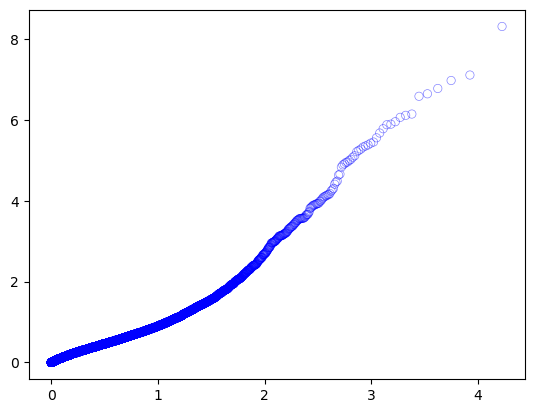

In [137]:
observed_quantiles = -np.log10(np.sort(wza['Z_pVal'].values))

# Expected quantiles from the uniform distribution
expected_quantiles = -np.log10(np.linspace(1 / len(wza), 1, len(wza)))

# QQ plot
sns.scatterplot(x = expected_quantiles, y = observed_quantiles, edgecolor='b', facecolor='none', alpha=0.5)
plt.plot([min(expected_quantiles), max(expected_quantiles)], [min(expected_quantiles), max(expected_quantiles)], 'r--')

plt.xlabel("Expected -log10(p-values)")
plt.ylabel("Observed -log10(p-values)")
plt.title(f'QQ Plot for {biovar}) WZA')

plt.show()

In [144]:
wza['chrom'] = wza['gene'].str.split('_').str[0].astype(int)
wza['pos'] = wza['gene'].str.split('_').str[1].astype(int)

In [145]:
min = wza.loc[wza['Z_pVal']!=0]['Z_pVal'].min()

In [146]:
wza.loc[wza['Z_pVal']==0]

,gene,SNPs,hits,Z,top_candidate_p,Z_pVal,chrom,pos


In [105]:
wza.loc[wza['Z_pVal']==0, 'Z_pVal'] = min

In [147]:
wza.sort_values('Z_pVal')

,gene,SNPs,hits,Z,top_candidate_p,Z_pVal,chrom,pos
482,1_1433,61,37,15.820157,4.699862e-58,4.854474e-09,1,1433
14829,5_2044,43,34,12.948745,5.164935e-60,7.720772e-08,5,2044
10964,4_1281,166,20,22.418576,7.807163e-16,1.054711e-07,4,1281
12533,4_2708,100,63,17.143231,2.371783e-99,1.660119e-07,4,2708
9505,3_302,41,27,12.284805,3.077006e-44,2.247724e-07,3,302
...,...,...,...,...,...,...,...,...
3826,1_4464,53,1,-13.018373,4.129632e-01,9.999993e-01,1,4464
16293,5_579,112,0,-17.633235,1.000000e+00,9.999995e-01,5,579
13345,4_694,27,0,-11.475399,1.000000e+00,9.999998e-01,4,694
5268,2_1116,26,0,-11.861792,1.000000e+00,9.999999e-01,2,1116


/tmp/ipykernel_1582741/1982253930.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


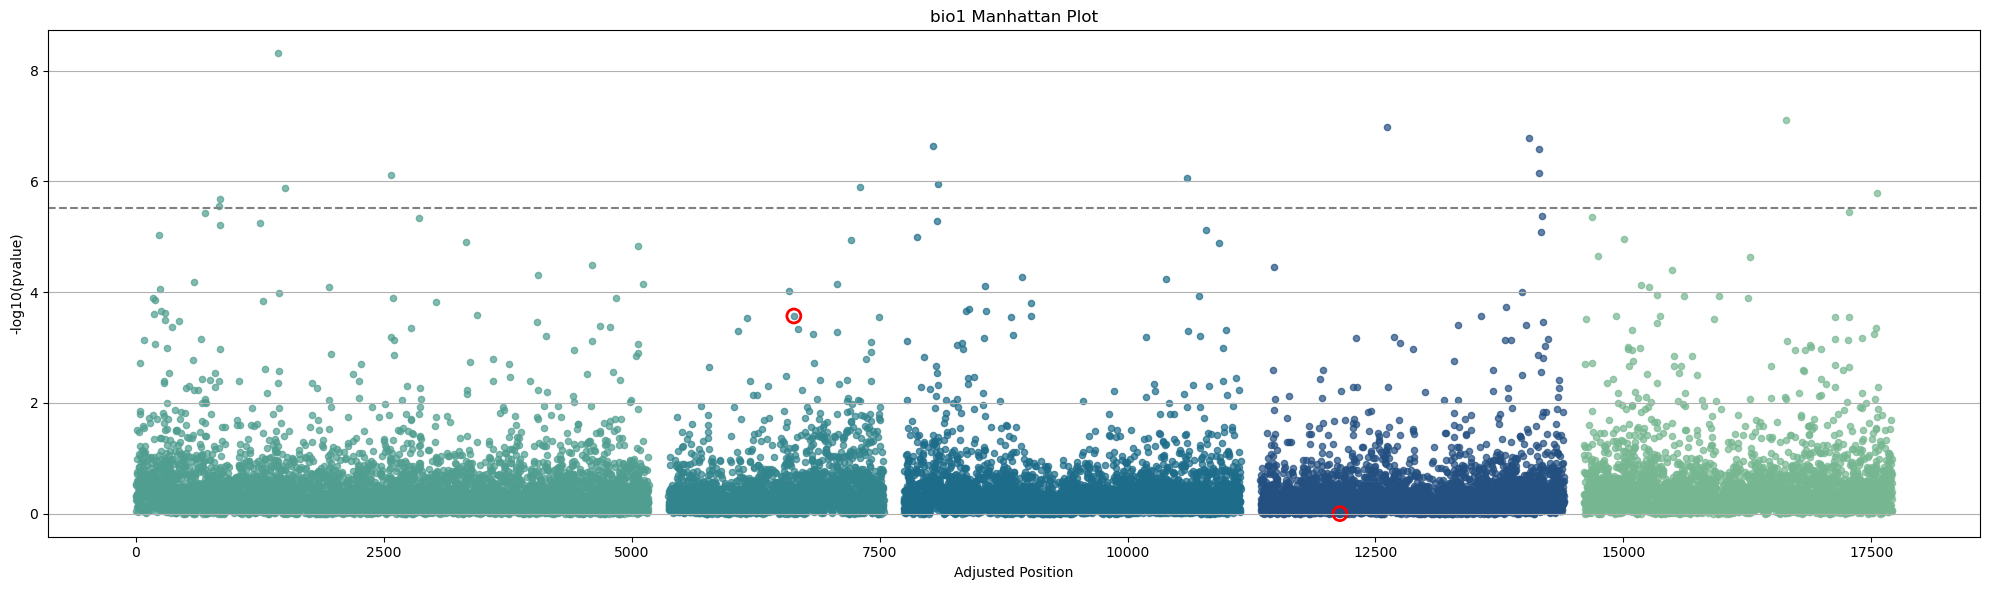

In [148]:
threshold_value = 0.05 / len(wza)
biovar='bio1'
#sm.qqplot(pvalues['pvalue'], line ='45') 
#py.show() 

df = wza[['Z_pVal','pos','chrom']].copy()


# Parsing chromosome number and position
df['chromosome'] = df['chrom']
df['position'] = df['pos']
df['-log10(pvalue)'] = -np.log10(df['Z_pVal'])

colors = sns.color_palette("crest", n_colors = 5)

# Calculate the offset for each chromosome to prevent overlap
chromosome_offsets = {}
offset = 0
for chrom in sorted(df['chromosome'].unique()):
    chromosome_offsets[chrom] = offset
    max_position = df[df['chromosome'] == chrom]['position'].max()
    offset += max_position + 200  # Buffer to prevent overlap

# Apply offsets to positions
df['adjusted_position'] = df.apply(lambda row: row['position'] + chromosome_offsets[row['chromosome']], axis=1)

# Normalize sizes for better visualization
size_transform = 2  # Adjust this factor as needed


# Create a color map based on `n_est`
#df['color'] = df['n_est'].map(lambda x: cmap(norm(x)))

# Creating the Manhattan plot
plt.figure(figsize=(20, 6))

for chrom in sorted(df['chromosome'].unique()):
    subset = df[df['chromosome'] == chrom]
    plt.scatter(
        subset['adjusted_position'],
        subset['-log10(pvalue)'],
        alpha=0.7,  # Transparency for better visibility
        c=colors[chrom % len(colors)], 
        label=f'Chr {chrom}',
            s= 20)

# Aesthetics
plt.xlabel('Adjusted Position')
plt.ylabel('-log10(pvalue)')
plt.title(f'{biovar} Manhattan Plot')  # Set the title
plt.grid(axis='y')


#genes = ['2_199', '3_2730', '5_2244']
genes = ['2_1265', '4_801']
# Add circles around the specific genes
for gene in genes:
    chrom, pos = map(int, gene.split('_'))
    subset_gene = df[(df['chromosome'] == chrom) & (df['position'] == pos)]
    if not subset_gene.empty:
        plt.scatter(
            subset_gene['adjusted_position'],
            subset_gene['-log10(pvalue)'],
            edgecolor='red',  # Color of the edge of the circle
            linewidth=2,      # Width of the edge line
            facecolor='none', # Facecolor of the circle (None means transparent)
            s=100,            # Size of the circle
            label=f'Gene {gene}'
        )
# Create a legend for the number of estimated lineages
#handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(norm(n)), markersize=10, label=f'Lineages {n}') for n in sorted(n_est_unique)]
#plt.legend(handles=handles, title="Estimated Lineages", bbox_to_anchor=(1.05, 1), loc='upper left')

# Threshold line
threshold = -np.log10(threshold_value)
plt.axhline(y=threshold, color='grey', linestyle='dashed')

# Show the plot
plt.tight_layout()
plt.show()


In [128]:
wza

,gene,SNPs,hits,Z,top_candidate_p,Z_pVal,chrom,pos
0,1_0,230,0,-1.071356,1.0,0.571603,1,0
1,1_1,4,0,-2.384460,1.0,0.884155,1,1
2,1_10,22,0,1.748989,1.0,0.189462,1,10
3,1_100,55,0,1.100985,1.0,0.318245,1,100
4,1_1000,10,0,1.100894,1.0,0.263559,1,1000
...,...,...,...,...,...,...,...,...
16752,5_995,48,0,-0.528624,1.0,0.558526,5,995
16753,5_996,3,0,-0.893466,1.0,0.656958,5,996
16754,5_997,29,0,-2.997831,1.0,0.896006,5,997
16755,5_998,9,0,-0.125998,1.0,0.496363,5,998


/tmp/ipykernel_1582741/847870600.py:38: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


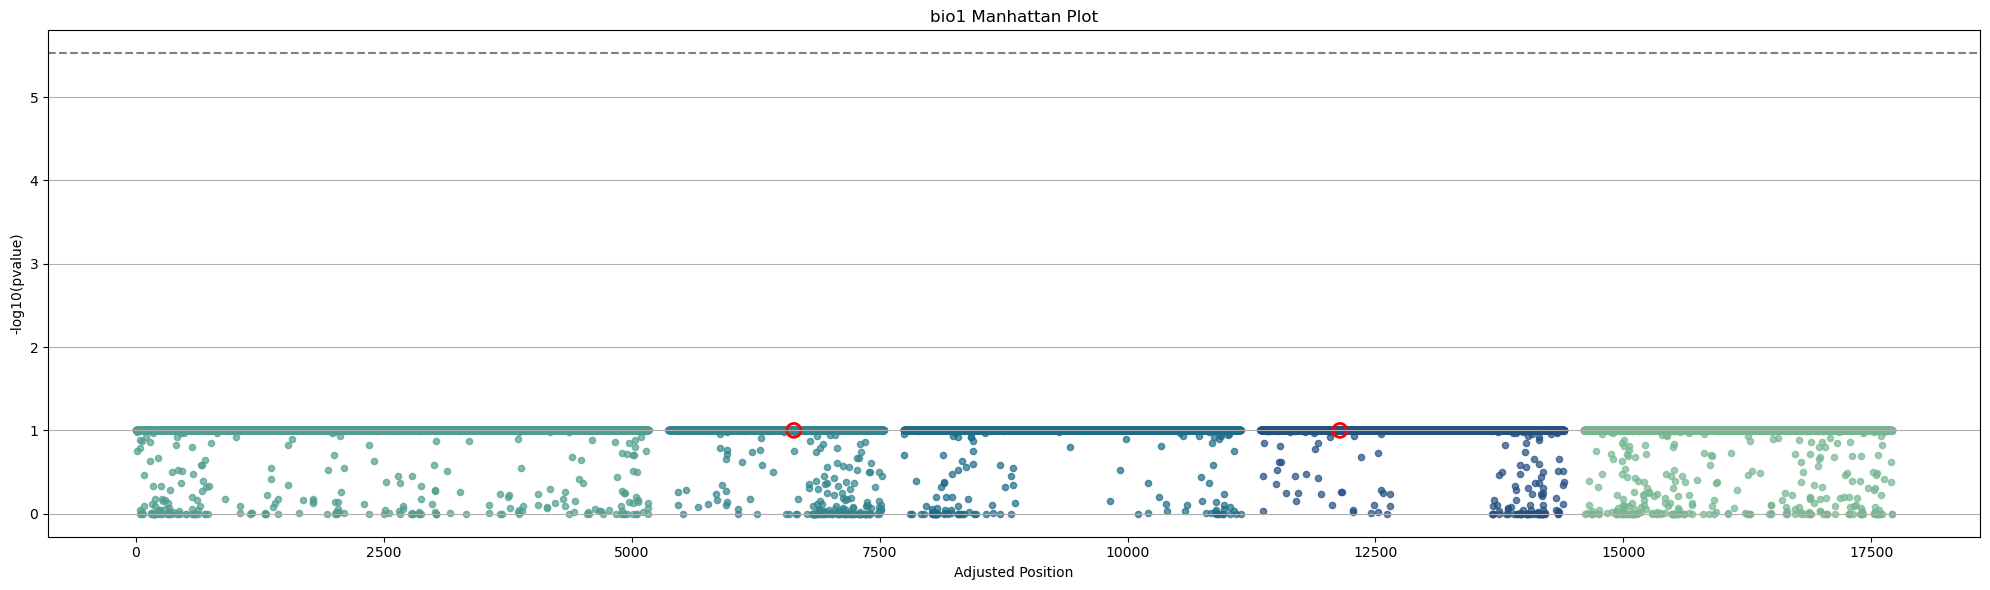

In [129]:

biovar='bio1'
#sm.qqplot(pvalues['pvalue'], line ='45') 
#py.show() 

df = wza[['top_candidate_p','pos','chrom']].copy()


# Parsing chromosome number and position
df['chromosome'] = df['chrom']
df['position'] = df['pos']
df['-log10(pvalue)'] =df['top_candidate_p']

colors = sns.color_palette("crest", n_colors = 5)

# Calculate the offset for each chromosome to prevent overlap
chromosome_offsets = {}
offset = 0
for chrom in sorted(df['chromosome'].unique()):
    chromosome_offsets[chrom] = offset
    max_position = df[df['chromosome'] == chrom]['position'].max()
    offset += max_position + 200  # Buffer to prevent overlap

# Apply offsets to positions
df['adjusted_position'] = df.apply(lambda row: row['position'] + chromosome_offsets[row['chromosome']], axis=1)

# Normalize sizes for better visualization
size_transform = 2  # Adjust this factor as needed


# Create a color map based on `n_est`
#df['color'] = df['n_est'].map(lambda x: cmap(norm(x)))

# Creating the Manhattan plot
plt.figure(figsize=(20, 6))

for chrom in sorted(df['chromosome'].unique()):
    subset = df[df['chromosome'] == chrom]
    plt.scatter(
        subset['adjusted_position'],
        subset['-log10(pvalue)'],
        alpha=0.7,  # Transparency for better visibility
        c=colors[chrom % len(colors)], 
        label=f'Chr {chrom}',
            s= 20)

# Aesthetics
plt.xlabel('Adjusted Position')
plt.ylabel('-log10(pvalue)')
plt.title(f'{biovar} Manhattan Plot')  # Set the title
plt.grid(axis='y')


#genes = ['2_199', '3_2730', '5_2244']
genes = ['2_1265', '4_801']
# Add circles around the specific genes
for gene in genes:
    chrom, pos = map(int, gene.split('_'))
    subset_gene = df[(df['chromosome'] == chrom) & (df['position'] == pos)]
    if not subset_gene.empty:
        plt.scatter(
            subset_gene['adjusted_position'],
            subset_gene['-log10(pvalue)'],
            edgecolor='red',  # Color of the edge of the circle
            linewidth=2,      # Width of the edge line
            facecolor='none', # Facecolor of the circle (None means transparent)
            s=100,            # Size of the circle
            label=f'Gene {gene}'
        )
# Create a legend for the number of estimated lineages
#handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(norm(n)), markersize=10, label=f'Lineages {n}') for n in sorted(n_est_unique)]
#plt.legend(handles=handles, title="Estimated Lineages", bbox_to_anchor=(1.05, 1), loc='upper left')

# Threshold line

plt.axhline(y=threshold, color='grey', linestyle='dashed')

# Show the plot
plt.tight_layout()
plt.show()


In [5]:
block_origin_bio1 = pd.read_csv('../key_files/block_origin_bio1_1001g.csv')

In [6]:
block_origin_bio1

,blocks,snp_origin_bio1
0,1_0,-0.026863
1,1_1,0.001980
2,1_10,0.073968
3,1_100,-0.033849
4,1_1000,-0.228123
...,...,...
16912,5_995,0.043812
16913,5_996,0.025821
16914,5_997,0.016168
16915,5_998,-0.008437


In [7]:
sign_results = [i for i in os.listdir('binom_reg/') if 'sign' in i]

In [6]:
sites = pd.Series(sign_results).str.split('_').str[-1].str.replace('.csv', '').astype(int).reset_index()

sites.columns = ['ign', 'site']

In [7]:
#clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/bioclimvars_experimental_sites_era5.csv')
clim_sites_during_exp = pd.read_csv('../key_files/bioclimvars_experimental_sites_era5.csv')

clim_sites_during_exp = clim_sites_during_exp[['site', 'bio1']]

clim_sites_during_exp = clim_sites_during_exp.merge(sites['site'])

clim_sites_during_exp_ordered = clim_sites_during_exp.sort_values('bio1')

unique_sites = clim_sites_during_exp_ordered['site'].values

In [10]:
unique_sites

array([24, 27, 48,  1, 42, 46, 25, 55, 49, 52, 57, 53, 54,  9, 12, 11,  6,
        5,  2, 45, 28,  4, 32, 43, 13, 10])

In [11]:
i = 24

In [12]:
wza = pd.read_csv(f'binom_reg/wza_site_{i}.csv')

In [13]:
wza

,gene,SNPs,hits,Z,top_candidate_p,Z_pVal
0,1_0,230,9,-2.708156,0.000587,0.709343
1,1_1,4,0,-1.747527,1.000000,0.831515
2,1_10,22,0,1.924007,1.000000,0.186373
3,1_100,55,0,-1.992862,1.000000,0.778240
4,1_1000,10,0,-0.689811,1.000000,0.643249
...,...,...,...,...,...,...
16752,5_995,48,0,1.793900,1.000000,0.243791
16753,5_996,3,0,-0.922186,1.000000,0.697147
16754,5_997,29,0,-0.201575,1.000000,0.540640
16755,5_998,9,0,0.384973,1.000000,0.424985


In [13]:
## addd where the block comes from and also add the mean of the slope for that block 
for i in unique_sites:
    print(i)
    wza = pd.read_csv(f'binom_reg/wza_site_{i}.csv')
    result_site = pd.read_csv(f'binom_reg/site_{i}.csv')
    result_site['block'] = result_site['id'].map(reverse_mapping)
    slopes = result_site.groupby('block')['slope'].median().reset_index()
    wza = wza.merge(slopes, left_on='gene', right_on = 'block').merge(block_origin_bio1, left_on='gene', right_on = 'blocks')
    wza.to_csv(f'binom_reg/wza_site_{i}_pr.csv',index=None)

24
27
48
1
42
46
25
55
49
52
57
53
54
9
12
11
6
5
2
45
28
4
32
43
13
10


In [121]:
site = pd.read_csv(f'binom_reg/wza_site_{site_value}_pr.csv')

In [19]:
len(unique_sites)

26

In [132]:
pd.read_csv(f'binom_reg/wza_site_{4}_pr.csv')

,gene,SNPs,hits,Z,top_candidate_p,Z_pVal,block,slope,blocks,snp_origin_bio1
0,1_0,230,0,-1.071356,1.0,0.567224,1_0,0.051220,1_0,-0.026863
1,1_1,4,0,-2.384460,1.0,0.887435,1_1,0.072292,1_1,0.001980
2,1_10,22,0,1.748989,1.0,0.189224,1_10,0.415244,1_10,0.073968
3,1_100,55,0,1.100985,1.0,0.319687,1_100,-0.329703,1_100,-0.033849
4,1_1000,10,0,1.100894,1.0,0.262202,1_1000,-0.515554,1_1000,-0.228123
...,...,...,...,...,...,...,...,...,...,...
16752,5_995,48,0,-0.528624,1.0,0.557259,5_995,-0.308736,5_995,0.043812
16753,5_996,3,0,-0.893466,1.0,0.659656,5_996,0.180606,5_996,0.025821
16754,5_997,29,0,-2.997831,1.0,0.895331,5_997,0.156857,5_997,0.016168
16755,5_998,9,0,-0.125998,1.0,0.496822,5_998,-0.233770,5_998,-0.008437


In [ ]:
import math

def log_odds_to_probability(log_odds):
    return 1 / (1 + np.exp(-log_odds))


24
27
48
1
42
46
25
55
49
52
57
53
54
9
12
11
6
5
2
45
28
4
32
43


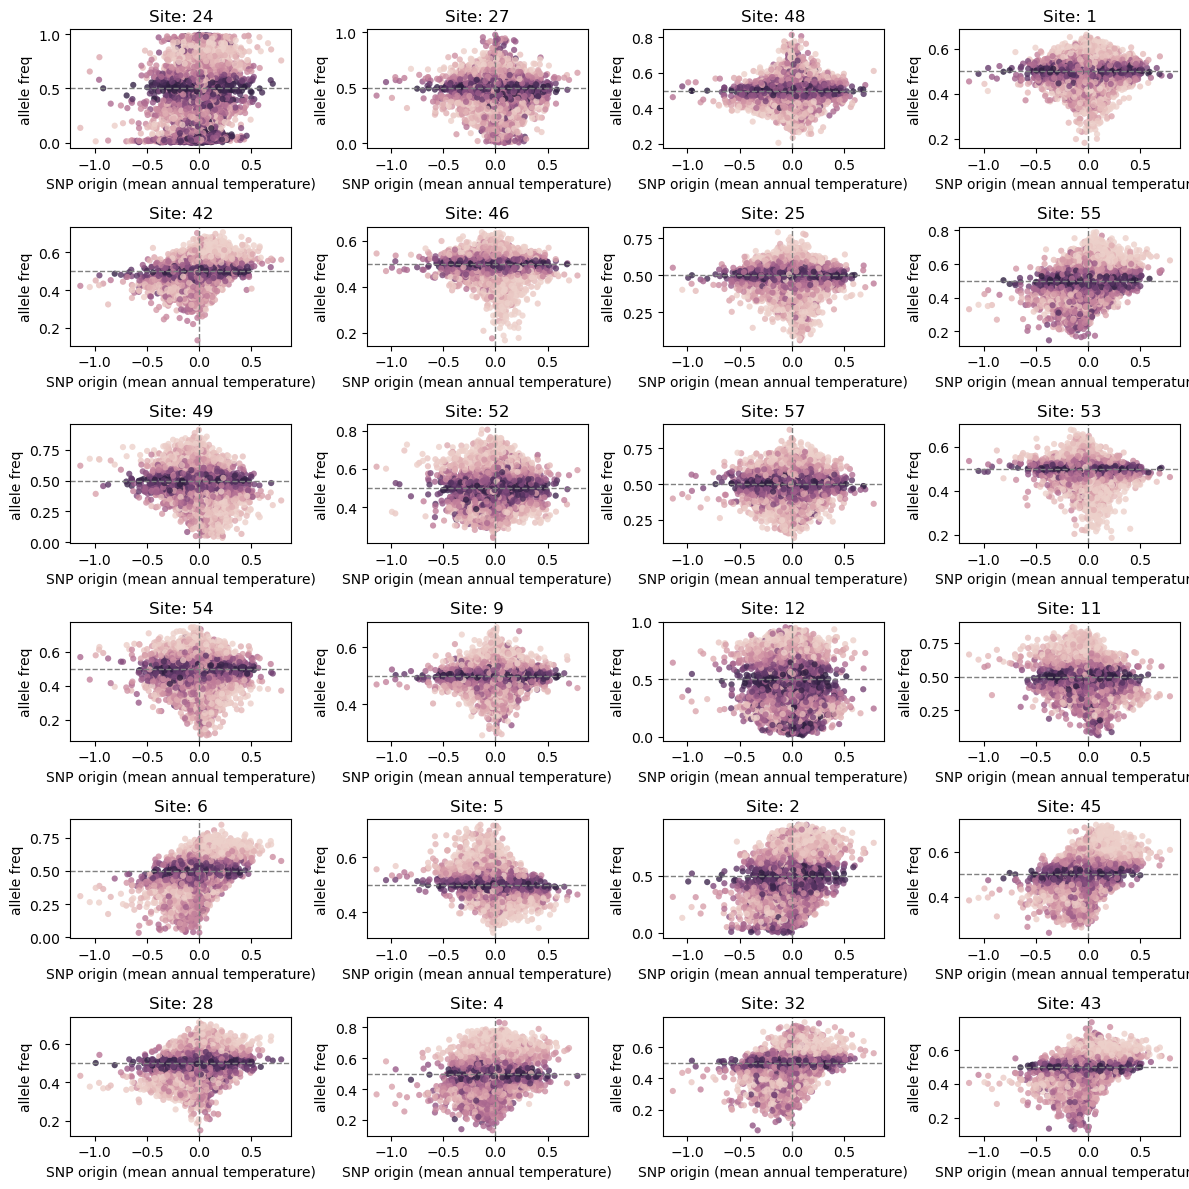

In [54]:
# Assuming results_sign is a list of filenames and snp_origin_bio1 is a DataFrame
n_plots = 6  # Number of subplots

# Create a grid of subplots with shared x and y axes
fig, axes = plt.subplots(nrows=n_plots, ncols=4, figsize=(12, 2 * n_plots))

# Flatten the axes array to iterate over it as a 1D list
axes = axes.flatten()

# Loop through results_sign and plot each site
for i, (ax, site_value) in enumerate(zip(axes, unique_sites)):
    site = pd.read_csv(f'binom_reg/wza_site_{site_value}_pr.csv')
    print(site_value)
    #threshold_value = 0.05 / len(site)

    #site = site[site['Z_pVal'] < threshold_value]
    site['slope'] = log_odds_to_probability(site['slope'])
    # Define quadrants
    site['quadrant'] = site.apply(
        lambda row: 'Q1' if row['snp_origin_bio1'] > 0 and row['slope'] > 0 else 
                    'Q2' if row['snp_origin_bio1'] < 0 and row['slope'] > 0 else
                    'Q3' if row['snp_origin_bio1'] < 0 and row['slope'] < 0 else
                    'Q4', axis=1)
    
    # Create a scatter plot for each result on its corresponding subplot
    sns.scatterplot(
        data=site,
        x='snp_origin_bio1',
        y='slope',
        hue='Z_pVal',  # Color by quadrant
        #palette={"Q1": "#C41E3A", "Q2": "#0047AB", "Q3": "grey", "Q4": "grey"},  # Assign colors to quadrants
        edgecolor="none",
        alpha=0.8,
        s=20,
        ax=ax,
        legend=False
    )
    
    # Set title for each subplot
    ax.set_title(f"Site: {site_value}")
    
    # Add dotted grey horizontal and vertical lines at y=0 and x=0
    ax.axhline(0.5, color='grey', linestyle='--', linewidth=1)
    ax.axvline(0, color='grey', linestyle='--', linewidth=1)
    # Set axis labels for each subplot
    ax.set_xlabel("SNP origin (mean annual temperature)")  # Change X-axis label
    ax.set_ylabel("allele freq")  # Change Y-axis label
    
# If there are more axes (subplots) than data, hide the empty ones
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])



# Adjust layout and show the figure
plt.tight_layout()
plt.savefig('block_origin_across_time.png')
plt.show()


In [57]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42 

24
27
48
1
42
46
25
55
49
52
57
53
54
9
12
11
6
5
2
45
28
4
32
43


/tmp/ipykernel_1711746/504764425.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


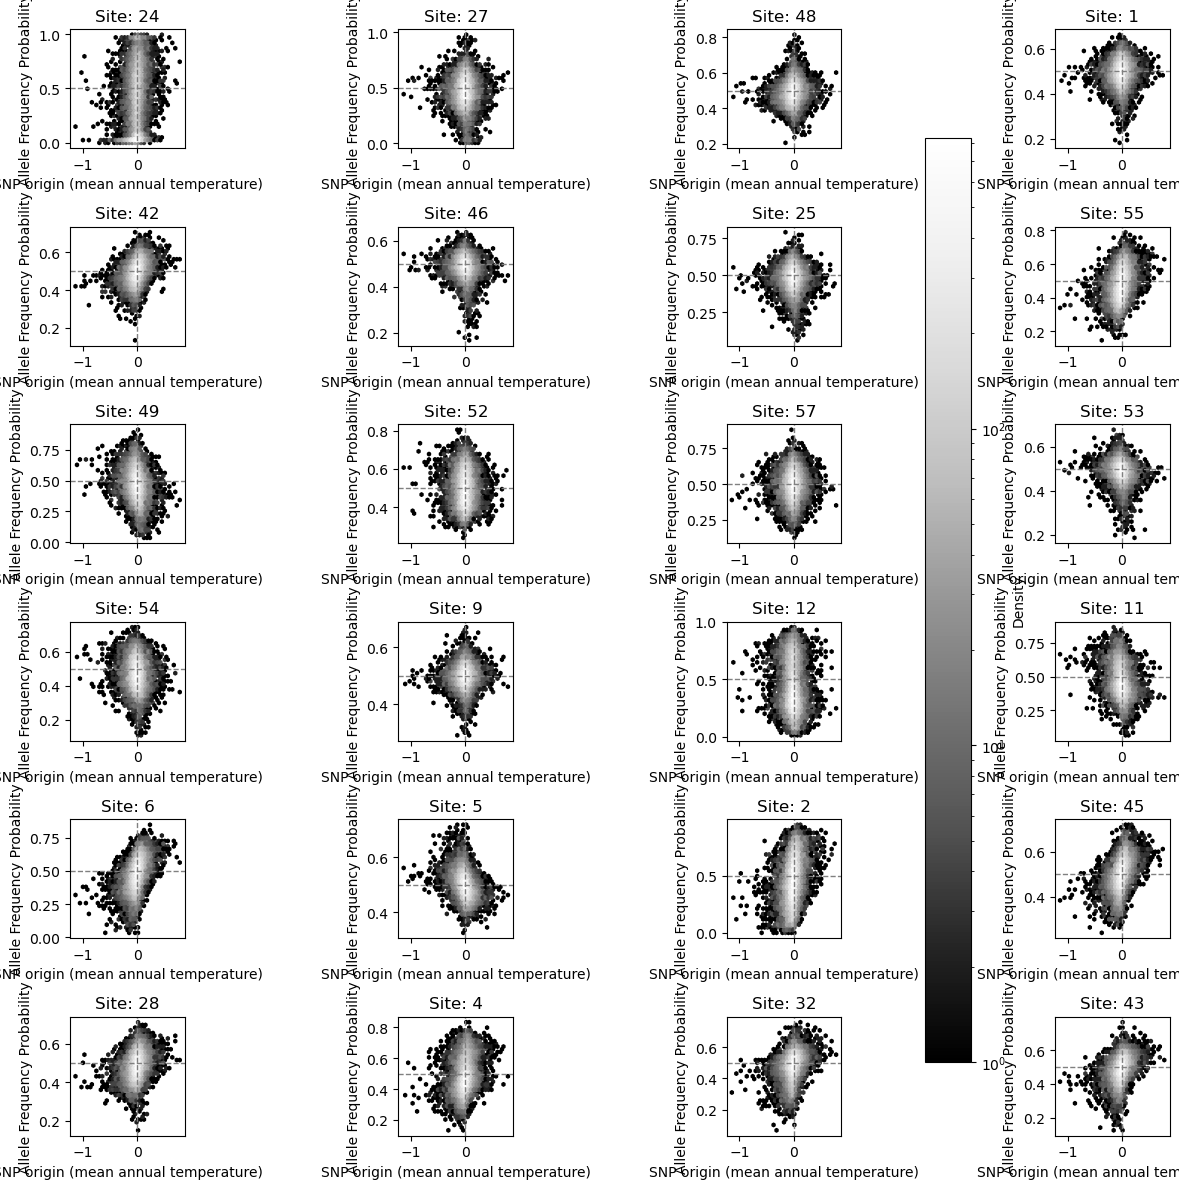

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming results_sign is a list of filenames and snp_origin_bio1 is a DataFrame
n_plots = 6  # Number of subplots

# Create a grid of subplots with shared x and y axes
fig, axes = plt.subplots(nrows=n_plots, ncols=4, figsize=(12, 2 * n_plots))

# Flatten the axes array to iterate over it as a 1D list
axes = axes.flatten()

# To ensure consistent color scaling across all plots, you can optionally define a norm
norm = plt.Normalize(site['slope'].min(), site['slope'].max())

# Loop through results_sign and plot each site
for i, (ax, site_value) in enumerate(zip(axes, unique_sites)):
    site = pd.read_csv(f'binom_reg/wza_site_{site_value}_pr.csv')
    print(site_value)

    # Convert log odds to probabilities
    site['slope'] = log_odds_to_probability(site['slope'])

    # Create a hexbin plot for each result on its corresponding subplot
    hb = ax.hexbin(
        site['snp_origin_bio1'],
        site['slope'],
        gridsize=35,  # Specifies the number of hexagons in the x-direction, adjust as needed
        cmap='Greys_r',  # Color map for density
        #mincnt=1,  # Minimum count of points to color a hexagon
        #norm=norm,  # Use the defined normalization for consistent coloring
        #reduce_C_function=np.mean  # Function to reduce C within each bin
        bins='log',  # Use logarithmic counts for coloring
        mincnt=1  # Minimum count number to display a hexagon
    )

    # Set title for each subplot
    ax.set_title(f"Site: {site_value}")
    
    # Add dotted grey horizontal and vertical lines at y=0.5 and x=0
    ax.axhline(0.5, color='grey', linestyle='--', linewidth=1)
    ax.axvline(0, color='grey', linestyle='--', linewidth=1)
    
    # Set axis labels for each subplot
    ax.set_xlabel("SNP origin (mean annual temperature)")
    ax.set_ylabel("Allele Frequency Probability")

# Place a single colorbar for all subplots to the right of the figure
#fig.colorbar(hb, ax=axes.ravel().tolist(), orientation='vertical', label='Density', labelpad=10)
# Create the colorbar and store it in a variable
cbar = fig.colorbar(hb, ax=axes.ravel().tolist(), orientation='vertical', label='Density',pad=1.2)

# Adjust the label position directly
#cbar.set_label('Density', labelpad=50)  # You can adjust the labelpad here as well for finer control

# Alternatively, manipulate the position more manually
#cbar.ax.get_yaxis().label.set_position((3, 0.5))  
# If there are more axes (subplots) than data, hide the empty ones
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout and show the figure
plt.tight_layout()
plt.savefig('colorpar.pdf')
plt.show()


24
27
48
1
42
46
25
55
49
52
57
53
54
9
12
11
6
5
2
45
28
4
32
43


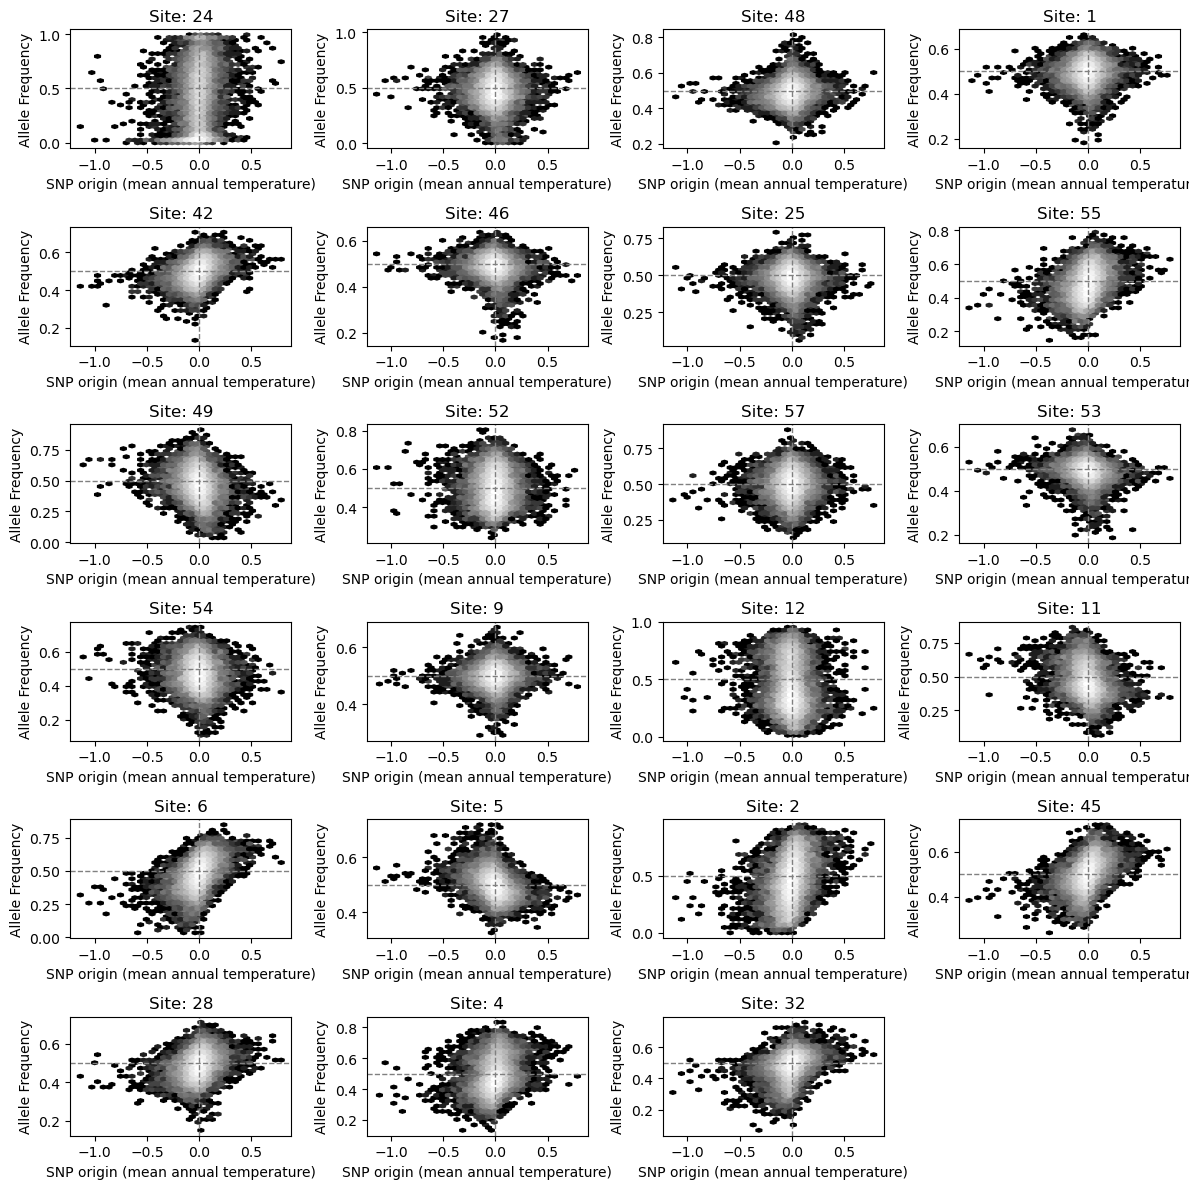

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming results_sign is a list of filenames and snp_origin_bio1 is a DataFrame
n_plots = 6  # Number of subplots

# Create a grid of subplots with shared x and y axes
fig, axes = plt.subplots(nrows=n_plots, ncols=4, figsize=(12, 2 * n_plots))

# Flatten the axes array to iterate over it as a 1D list
axes = axes.flatten()

# To ensure consistent color scaling across all plots, you can optionally define a norm
norm = plt.Normalize(site['slope'].min(), site['slope'].max())

# Loop through results_sign and plot each site
for i, (ax, site_value) in enumerate(zip(axes, unique_sites)):
    site = pd.read_csv(f'binom_reg/wza_site_{site_value}_pr.csv')
    print(site_value)

    # Convert log odds to probabilities
    site['slope'] = log_odds_to_probability(site['slope'])

    # Create a hexbin plot for each result on its corresponding subplot
    hb = ax.hexbin(
        site['snp_origin_bio1'],
        site['slope'],
        gridsize=35,  # Specifies the number of hexagons in the x-direction, adjust as needed
        cmap='Greys_r',  # Color map for density
        #mincnt=1,  # Minimum count of points to color a hexagon
        #norm=norm,  # Use the defined normalization for consistent coloring
        #reduce_C_function=np.mean  # Function to reduce C within each bin
        bins='log',  # Use logarithmic counts for coloring
        mincnt=1  # Minimum count number to display a hexagon
    )

    # Set title for each subplot
    ax.set_title(f"Site: {site_value}")
    
    # Add dotted grey horizontal and vertical lines at y=0.5 and x=0
    ax.axhline(0.5, color='grey', linestyle='--', linewidth=1)
    ax.axvline(0, color='grey', linestyle='--', linewidth=1)
    
    # Set axis labels for each subplot
    ax.set_xlabel("SNP origin (mean annual temperature)")
    ax.set_ylabel("Allele Frequency")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
# Configure the last subplot for the colorbar
cbar_ax = axes[-1]  # Use the last subplot for the colorbar
fig.colorbar(hb, cax=cbar_ax, orientation='vertical', label='Density')
cbar_ax.set_visible(False)  # Hide the axes of the last subplot, only show the colorbar




# Adjust layout and show the figure
plt.tight_layout()
plt.savefig('block_origin_across_time_hexbin.pdf')
plt.show()


In [9]:
site = pd.read_csv(f'binom_reg/wza_site_{site_value}_pr.csv')


0        0.020427
1        0.298556
2        0.307007
3        0.000903
4       -0.579725
           ...   
16752    0.053217
16753    0.328258
16754    0.300865
16755    0.033517
16756   -0.034354
Name: slope, Length: 16757, dtype: float64

0        0.505107
1        0.574090
2        0.576154
3        0.500226
4        0.358996
           ...   
16752    0.513301
16753    0.581335
16754    0.574654
16755    0.508379
16756    0.491412
Name: slope, Length: 16757, dtype: float64

In [ ]:
## 49 45 

In [83]:
site5 = pd.read_csv(f'binom_reg/wza_site_5_pr.csv')

site25 = pd.read_csv(f'binom_reg/wza_site_25_pr.csv')

site25 = site25[['block', 'Z_pVal', 'slope', 'snp_origin_bio1']]

site25.columns = ['block', 'Z_pVal_site25', 'slope_site25', 'snp_origin_bio1']

site5 = site5[['block', 'Z_pVal', 'slope', 'snp_origin_bio1']]

site5.columns = ['block', 'Z_pVal_site5', 'slope_site5', 'snp_origin_bio1']

merged = site5.merge(site25)

merged['combined_Z_pVal'] = (merged['Z_pVal_site5'] + merged['Z_pVal_site25']) / 2  # Average example


merged['Z_pVal_site25_log'] = -np.log10(merged['Z_pVal_site25'])

merged['Z_pVal_site5_log'] = -np.log10(merged['Z_pVal_site5'])

In [84]:


wza_lfmm = pd.read_csv('../wza/wza_results_lfmm_bio1_poly7.csv')
wza_kendall = pd.read_csv('../wza/wza_kendalltau_results_bio1_poly7.csv')
binomial_sp = pd.read_csv('../wza/wza_binomial_regression_bio1_poly7.csv')


sign_wza_lfmm = wza_lfmm[wza_lfmm['Z_pVal'] < 0.05/len(wza_lfmm)]['gene'].values

sign_wza_kendall = wza_kendall[wza_kendall['Z_pVal'] < 0.05/len(wza_kendall)]['gene'].values

sign_binomial_sp = binomial_sp[binomial_sp['Z_pVal'] < 0.05/len(binomial_sp)]['gene'].values

merged['color'] = 'grey'

merged.loc[merged['block'].isin(sign_wza_lfmm), 'color'] = 'green'
merged.loc[merged['block'].isin(sign_wza_kendall), 'color'] = 'orange'
merged.loc[merged['block'].isin(sign_binomial_sp), 'color'] = 'purple'

significant = merged[merged['color'] != 'grey']
non_significant = merged[merged['color'] == 'grey']

In [85]:
#sites_names = pd.read_csv('../key_files/sites_simple_names.csv')

In [86]:
sign = pd.read_csv('../signficant_intersection/genes_info_BH_tair10.csv')

sign = sign[sign['gen']!='first_gen']

sign = sign.drop_duplicates('block_id')

In [87]:
merged

,block,Z_pVal_site5,slope_site5,snp_origin_bio1,Z_pVal_site25,slope_site25,combined_Z_pVal,Z_pVal_site25_log,Z_pVal_site5_log,color
0,1_0,0.693514,0.031661,-0.026863,0.379147,-0.072175,0.536331,0.421192,0.158945,grey
1,1_1,0.351791,-0.123370,0.001980,0.583736,-0.395529,0.467763,0.233784,0.453715,grey
2,1_10,0.477323,-0.184963,0.073968,0.755646,-0.200070,0.616484,0.121682,0.321188,grey
3,1_100,0.027189,-0.026791,-0.033849,0.863679,-0.098836,0.445434,0.063648,1.565601,grey
4,1_1000,0.252518,-0.186941,-0.228123,0.431412,0.137556,0.341965,0.365108,0.597707,grey
...,...,...,...,...,...,...,...,...,...,...
16752,5_995,0.420126,-0.057830,0.043812,0.314093,0.104304,0.367109,0.502942,0.376621,grey
16753,5_996,0.121732,-0.330325,0.025821,0.319050,0.228791,0.220391,0.496141,0.914596,grey
16754,5_997,0.132994,-0.270392,0.016168,0.409727,0.275157,0.271361,0.387505,0.876167,grey
16755,5_998,0.548659,-0.005151,-0.008437,0.565681,-0.220661,0.557170,0.247429,0.260698,grey


In [88]:
merged['sign'] = False

In [89]:
merged.loc[merged['block'].isin(sign['block_id']), 'sign'] = True

In [90]:
merged = merged.merge(sign, left_on='block', right_on = 'block_id', how='outer')




In [91]:
merged

,block,Z_pVal_site5,slope_site5,snp_origin_bio1,Z_pVal_site25,slope_site25,combined_Z_pVal,Z_pVal_site25_log,Z_pVal_site5_log,color,sign,block_id,model,gen,source,gene_name,description
0,1_0,0.693514,0.031661,-0.026863,0.379147,-0.072175,0.536331,0.421192,0.158945,grey,False,NaN,NaN,NaN,NaN,NaN,NaN
1,1_1,0.351791,-0.123370,0.001980,0.583736,-0.395529,0.467763,0.233784,0.453715,grey,False,NaN,NaN,NaN,NaN,NaN,NaN
2,1_10,0.477323,-0.184963,0.073968,0.755646,-0.200070,0.616484,0.121682,0.321188,grey,False,NaN,NaN,NaN,NaN,NaN,NaN
3,1_100,0.027189,-0.026791,-0.033849,0.863679,-0.098836,0.445434,0.063648,1.565601,grey,False,NaN,NaN,NaN,NaN,NaN,NaN
4,1_1000,0.252518,-0.186941,-0.228123,0.431412,0.137556,0.341965,0.365108,0.597707,grey,False,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16752,5_995,0.420126,-0.057830,0.043812,0.314093,0.104304,0.367109,0.502942,0.376621,grey,False,NaN,NaN,NaN,NaN,NaN,NaN
16753,5_996,0.121732,-0.330325,0.025821,0.319050,0.228791,0.220391,0.496141,0.914596,grey,False,NaN,NaN,NaN,NaN,NaN,NaN
16754,5_997,0.132994,-0.270392,0.016168,0.409727,0.275157,0.271361,0.387505,0.876167,grey,False,NaN,NaN,NaN,NaN,NaN,NaN
16755,5_998,0.548659,-0.005151,-0.008437,0.565681,-0.220661,0.557170,0.247429,0.260698,grey,False,NaN,NaN,NaN,NaN,NaN,NaN


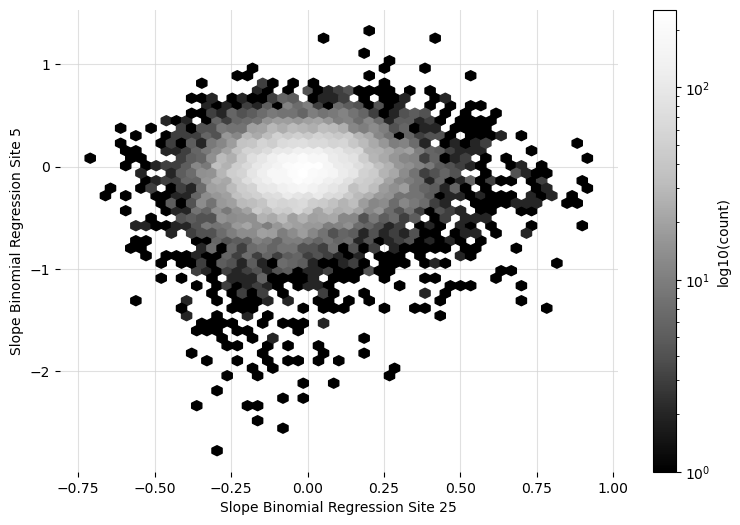

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(9, 6))


# Create a hexbin plot with a color bar
hb = ax.hexbin(
    data=merged, x='slope_site5', y='slope_site25', 
    
    gridsize=50,  # Size of the hexagons
    cmap='Greys_r',  # Color map for the hexbins
    bins='log',  # Use logarithmic counts for coloring
    mincnt=1  # Minimum count number to display a hexagon
)

# Create a color bar for the hexbin plot
cb = fig.colorbar(hb, ax=ax)
cb.set_label('log10(count)')

# Filter the data where 'sign' is True
significant_points = merged[merged['sign'] == True]




dark_grey = '#4D4D4D'  # Define dark grey color
plt.grid(True, color='lightgrey', alpha=0.7, zorder=0)

# Apply to spines
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Set labels and title
plt.ylabel('Slope Binomial Regression Site 5')
plt.xlabel('Slope Binomial Regression Site 25')
#ax.set_title('Density of Points with Hexbin Plot')

# Add a legend to the plot
#ax.legend(title='Point Significance')
#plt.savefig('blocks_ant_pleio.pdf')
plt.show()

In [122]:
non_significant

,block,Z_pVal_site46,slope_site46,snp_origin_bio1,Z_pVal_site13,slope_site13,combined_Z_pVal,color
0,1_0,0.762700,-0.046229,-0.026863,0.897054,0.021382,0.829877,grey
1,1_1,0.157904,-0.452829,0.001980,0.751111,0.232675,0.454507,grey
2,1_10,0.263933,-0.122826,0.073968,0.722422,-0.068535,0.493178,grey
3,1_100,0.886569,0.020930,-0.033849,0.794035,-0.105684,0.840302,grey
4,1_1000,0.377150,0.105566,-0.228123,0.424190,-0.202985,0.400670,grey
...,...,...,...,...,...,...,...,...
16752,5_995,0.854275,-0.072166,0.043812,0.873009,-0.002264,0.863642,grey
16753,5_996,0.193923,-0.320410,0.025821,0.862142,-0.022848,0.528033,grey
16754,5_997,0.177839,-0.272260,0.016168,0.999992,-0.000460,0.588915,grey
16755,5_998,0.865236,-0.042816,-0.008437,0.847655,0.049881,0.856445,grey


In [ ]:
# Fit a regression model using statsmodels
X = merged['slope_site25']
y = merged['slope_site5']

# Add constant (intercept) for statsmodels
X_with_intercept = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X_with_intercept).fit()

# Extract slope, p-value, and R-squared values
slope = model.params[1]
intercept = model.params[0]
p_value = model.pvalues[1]
r_squared = model.rsquared

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42 



import matplotlib.colors as mcolors

cmap = plt.cm.Purples(np.linspace(0.3, 1.5, 256))  # start from 30% into the Greens colormap
new_cmap = mcolors.LinearSegmentedColormap.from_list('truncated_greens', cmap)

new_cmap



# Sample data creation
# merged = pd.DataFrame(...) # Assuming you already have your merged DataFrame
plt.rcParams['axes.axisbelow'] = True

# Combine the Z_pVal columns into a new column
fig, ax = plt.subplots(figsize=(6, 3))

# Create the scatter plot


sns.scatterplot(data=merged, x='slope_site25', y='slope_site5', hue='Z_pVal_site25_log', # Use the density as color
    palette=new_cmap,  # Color mapping
                #s=50,  # Size for non-significant points
    edgecolor="none",  # Remove white edge around the dots
    alpha=0.9,  
                    legend = False)
                #) # Color mapping)


# Plot the regression line using seaborn
#sns.regplot(
#    x='slope_site25', y='slope_site5',
#    data=merged,
#    scatter=False,  # Do not plot the scatter again
#    line_kws={"color": "green", "alpha": 0.7},  # Customize the regression line
#    ci=None,  # Disable confidence interval
#)     


# Annotate the plot with slope, p-value, and R-squared
#if p_value < 1e-3:
#    p_value_text = "p-value < 1e-3"
#else:
#    p_value_text = f'P-value: {p_value:.3g}'

# Add the text box for the regression line info
#plt.text(
#    0.05, 0.98,  # X and Y position for annotation
#    f'Slope: {slope:.3f}\n{p_value_text}\n$R^2$: {r_squared:.3f}',  # Annotation text
#    fontsize=12, color="black",  # Font properties
#    ha='left', va='top',  # Text alignment
#    transform=ax.transAxes  # Ensure it's positioned relative to the axes
#)
#sns.scatterplot(data=significant, x='slope_site25', y='slope_site5', 
#               palette=['purple', 'green', 'orange'],  # Custom colors for significant points
#                hue='color', 
#                    s=100,  # Larger size for significant points
#    edgecolor="none",  # Remove white edge around the dots
#    alpha=0.6,  # Color for significant points
#                )

# Draw reference lines
#ax.axhline(0, color='grey', linestyle='--', linewidth=1)
#ax.axvline(0, color='grey', linestyle='--', linewidth=1)


# Create a color normalization object for the p-values
# Create a color normalization object for the p-values
norm = mcolors.Normalize(vmin=merged['Z_pVal_site25_log'].min(), vmax=merged['Z_pVal_site25_log'].max())
sm = plt.cm.ScalarMappable(cmap=new_cmap, norm=norm)
sm.set_array([])  # Only needed for older versions of matplotlib

# Add the color bar with reduced size and no borders
cbar = plt.colorbar(sm, ax=ax,)  # Adjust shrink value to make it smaller
cbar.set_label('Pvalues site 25', rotation=270, labelpad=15)  # Increase labelpad for more space
cbar.ax.invert_yaxis()  # Invert the color bar if needed
cbar.outline.set_visible(False)  # Remove border outline

# Add the color bar with reduced size and no borders
#cbar = plt.colorbar(sm, ax=ax, shrink=0.8)  # Adjust shrink value to make it smaller
#cbar.set_label('average_Z_pVal', rotation=270, labelpad=15)
#cbar.ax.invert_yaxis()  # Invert the color bar if needed
#cbar.outline.set_visible(False)  # Remove border outline

# Customize the color bar ticks
#cbar.ax.tick_params(size=0)  # Remove tick marks
#cbar.ax.set_position([0.8, 0.1, 0.02, 0.5])  # [left, bottom, width, height]
# Create a custom legend
#handles = [
#    plt.Line2D([0], [0], marker='o', color='w', label='LFMM', markerfacecolor='green', markersize=10),
#    plt.Line2D([0], [0], marker='o', color='w', label='Binomial Regression', markerfacecolor='purple', markersize=10),
#    plt.Line2D([0], [0], marker='o', color='w', label='Kendall', markerfacecolor='orange', markersize=10),
#]
#font_size = 12
#plt.rc('font', family='sans-serif', size=font_size)  # Regular font size
#plt.rc('axes', titlesize=font_size, labelsize=font_size)  # Title and label size for axes
#plt.rc('xtick', labelsize=font_size)  # X tick labels size
#plt.rc('ytick', labelsize=font_size)  # Y tick labels size

dark_grey = '#4D4D4D'  # Define dark grey color

# Apply to spines
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, color='lightgrey', alpha=0.7)

# Set tick parameters
plt.tick_params(axis='both', colors=dark_grey)  # Set tick colors

plt.ylabel('Slope Binomial Regression Site 5')
plt.xlabel('Slope Binomial Regression Site 25')

#plt.legend(handles=handles, loc='upper left', bbox_to_anchor=(1, 1))
#plt.savefig("blocks_Across_time_antagonisti_pleio.png", dpi = 300)  # Save as SVG
#plt.savefig("blocks_Across_space_antagonisti_pleio.pdf", format='pdf')  # Save as SVG
# Save and show the plot
#plt.savefig('snp_origin_across_space_alpha_size_significant_layered.png')
plt.show()

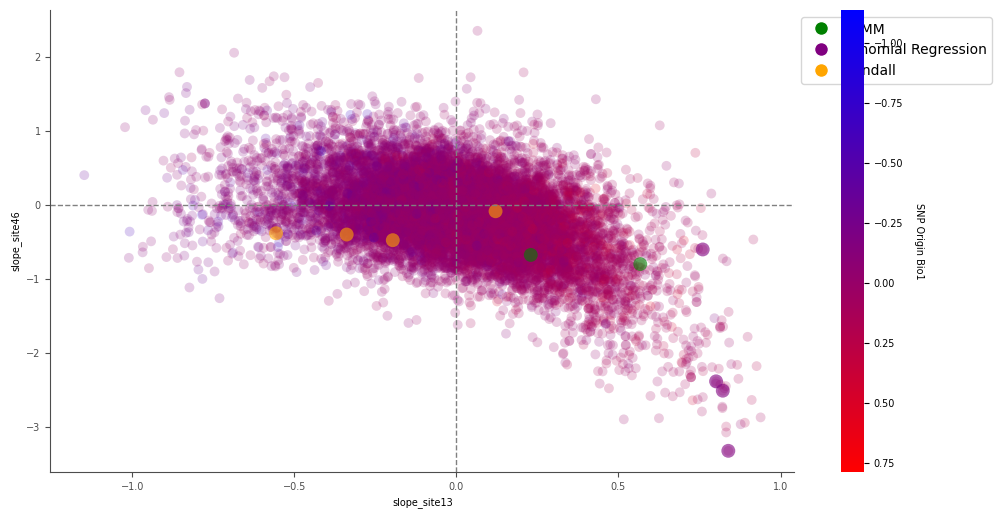

In [221]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

# Sample data creation
# merged = pd.DataFrame(...) # Assuming you already have your merged DataFrame

# Create a custom colormap from blue to red
custom_cmap = LinearSegmentedColormap.from_list('custom_blue_red', ['blue', 'red'], N=256)

# Create the scatter plot
fig, ax = plt.subplots(figsize=(12, 6))

# Scatter plot for non-significant points
sns.scatterplot(data=merged, x='slope_site25', y='slope_site5', hue='snp_origin_bio1', 
                palette=custom_cmap,  # Use the custom colormap
                s=50,  # Size for non-significant points
                edgecolor="none",  # Remove white edge around the dots
                alpha=0.2)

# Scatter plot for significant points
sns.scatterplot(data=significant, x='slope_site25', y='slope_site5', 
                palette=['purple', 'green', 'orange'],  # Custom colors for significant points
                hue='color', 
                s=100,  # Larger size for significant points
                edgecolor="none",  # Remove white edge around the dots
                alpha=0.6)

# Draw reference lines
ax.axhline(0, color='grey', linestyle='--', linewidth=1)
ax.axvline(0, color='grey', linestyle='--', linewidth=1)

# Create a color bar for the custom colormap
norm = mcolors.Normalize(vmin=merged['snp_origin_bio1'].min(), vmax=merged['snp_origin_bio1'].max())
sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
sm.set_array([])  # Only needed for older versions of matplotlib

# Add the color bar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('SNP Origin Bio1', rotation=270, labelpad=15)

# Customize the color bar ticks
cbar.ax.invert_yaxis()  # Invert the color bar if needed
cbar.outline.set_visible(False)  # Remove border outline

# Create a custom legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='LFMM', markerfacecolor='green', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Binomial Regression', markerfacecolor='purple', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Kendall', markerfacecolor='orange', markersize=10),
]

plt.rc('font', family='sans-serif', size=10, weight='normal')  # Regular font size
plt.rc('axes', titlesize=8, labelsize=7)  # Title and label size for axes
plt.rc('xtick', labelsize=7)  # X tick labels size
plt.rc('ytick', labelsize=7)  # Y tick labels size

dark_grey = '#4D4D4D'  # Define dark grey color

# Apply to spines
plt.gca().spines['left'].set_color(dark_grey)
plt.gca().spines['bottom'].set_color(dark_grey)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Set tick parameters
plt.tick_params(axis='both', colors=dark_grey)  # Set tick colors

plt.legend(handles=handles, loc='upper left', bbox_to_anchor=(1, 1))

# Save and show the plot
# plt.savefig('snp_origin_across_space_alpha_size_significant_layered.png')
plt.show()


In [123]:
merged

,block,Z_pVal_site46,slope_site46,snp_origin_bio1,Z_pVal_site13,slope_site13,combined_Z_pVal,color
0,1_0,0.762700,-0.046229,-0.026863,0.897054,0.021382,0.829877,grey
1,1_1,0.157904,-0.452829,0.001980,0.751111,0.232675,0.454507,grey
2,1_10,0.263933,-0.122826,0.073968,0.722422,-0.068535,0.493178,grey
3,1_100,0.886569,0.020930,-0.033849,0.794035,-0.105684,0.840302,grey
4,1_1000,0.377150,0.105566,-0.228123,0.424190,-0.202985,0.400670,grey
...,...,...,...,...,...,...,...,...
16752,5_995,0.854275,-0.072166,0.043812,0.873009,-0.002264,0.863642,grey
16753,5_996,0.193923,-0.320410,0.025821,0.862142,-0.022848,0.528033,grey
16754,5_997,0.177839,-0.272260,0.016168,0.999992,-0.000460,0.588915,grey
16755,5_998,0.865236,-0.042816,-0.008437,0.847655,0.049881,0.856445,grey


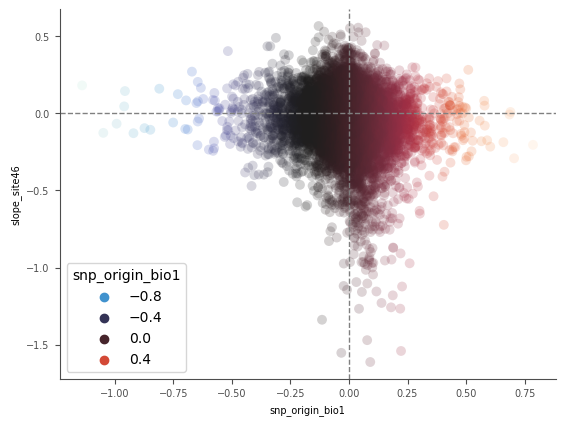

In [129]:
sns.scatterplot(data=merged, x='snp_origin_bio1', y='slope_site5', hue='snp_origin_bio1', # Use the density as color
                palette="icefire", 
                s=50,  # Size for non-significant points
    edgecolor="none",  # Remove white edge around the dots
    alpha=0.2, ) # Color mapping)
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)

plt.rc('font', family='sans-serif', size=10, weight='normal')  # Regular font size
plt.rc('axes', titlesize=8, labelsize=7)  # Title and label size for axes
plt.rc('xtick', labelsize=7)  # X tick labels size
plt.rc('ytick', labelsize=7)  # Y tick labels size

dark_grey = '#4D4D4D'  # Define dark grey color

# Apply to spines
plt.gca().spines['left'].set_color(dark_grey)
plt.gca().spines['bottom'].set_color(dark_grey)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Set tick parameters
plt.tick_params(axis='both', colors=dark_grey)  # Set tick colors


# Save and show the plot
# plt.savefig('snp_origin_across_space_alpha_size_significant_layered.png')
plt.show()

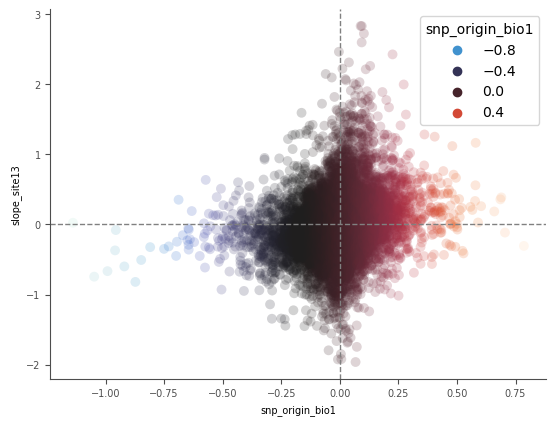

In [130]:
sns.scatterplot(data=merged, x='snp_origin_bio1', y='slope_site25', hue='snp_origin_bio1', # Use the density as color
                palette="icefire", 
                s=50,  # Size for non-significant points
    edgecolor="none",  # Remove white edge around the dots
    alpha=0.2, ) # Color mapping)
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)

plt.rc('font', family='sans-serif', size=10, weight='normal')  # Regular font size
plt.rc('axes', titlesize=8, labelsize=7)  # Title and label size for axes
plt.rc('xtick', labelsize=7)  # X tick labels size
plt.rc('ytick', labelsize=7)  # Y tick labels size

dark_grey = '#4D4D4D'  # Define dark grey color

# Apply to spines
plt.gca().spines['left'].set_color(dark_grey)
plt.gca().spines['bottom'].set_color(dark_grey)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Set tick parameters
plt.tick_params(axis='both', colors=dark_grey)  # Set tick colors


# Save and show the plot
# plt.savefig('snp_origin_across_space_alpha_size_significant_layered.png')
plt.show()

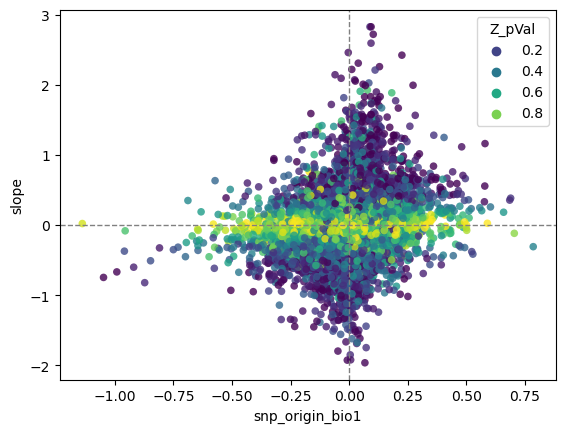

In [19]:
sns.scatterplot(
    data=site10,
    x='snp_origin_bio1',
    y='slope',
    hue='Z_pVal',
    palette="viridis",
    #hue='quadrant',  # Color by quadrant
    #palette={"Q1": "#C41E3A", "Q2": "#0047AB", "Q3": "grey", "Q4": "grey"},  # Assign colors to quadrants
    edgecolor="none",
    alpha=0.8,
    s=30,
)
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)

In [ ]:
site5 = site5.merge(snp_origin_bio1, on='id')
    
# Create a scatter plot for each result on its corresponding subplot
sns.scatterplot(
    data=site5,
    x='snp_origin_bio1',
    y='slope',
    hue='p_value',
    palette="viridis",
    edgecolor="none",
    alpha=0.3,
    s=50,
    legend=False
)

# Set title for each subplot
ax.set_title(f"Scatter Plot for {site_value}")
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)

24
27
48
1
42
46
25
55
49
52
57
53
54
9
12
11
6
5
2
45
28
4
32
43
13
10


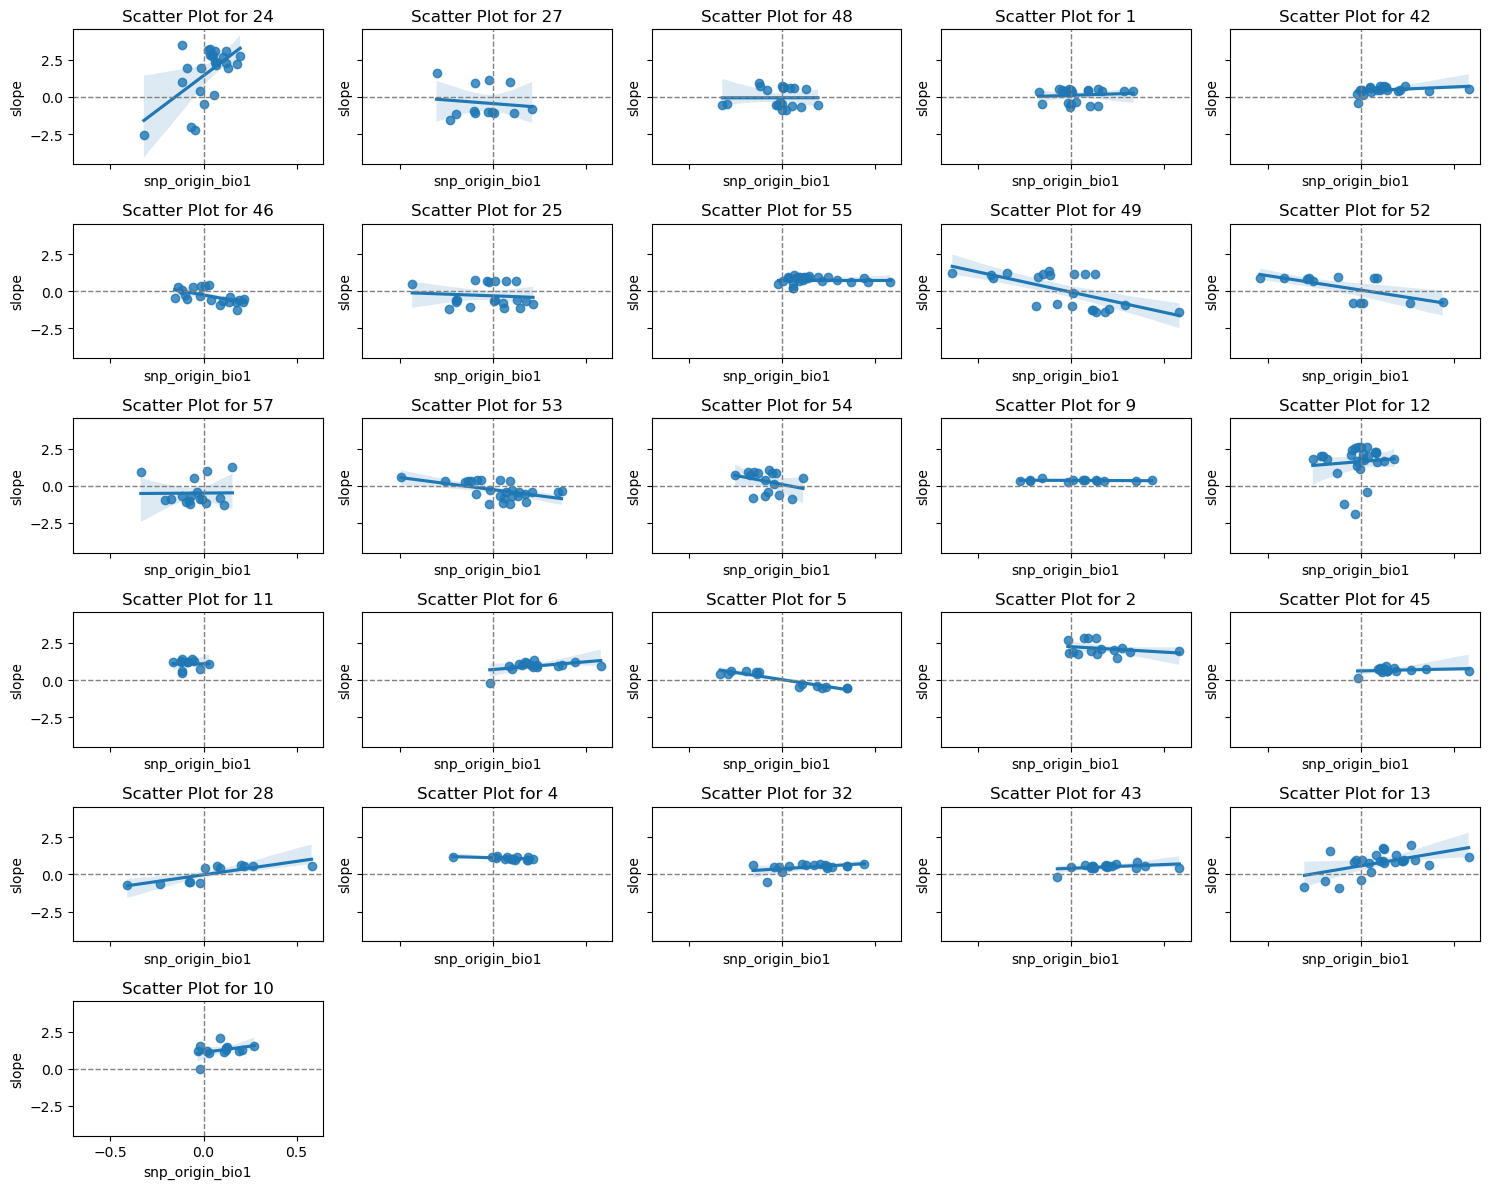

In [26]:
# Assuming results_sign is a list of filenames and snp_origin_bio1 is a DataFrame
n_plots = 6  # Number of subplots

# Create a grid of subplots with shared x and y axes
fig, axes = plt.subplots(nrows=n_plots, ncols=5, figsize=(15, 2 * n_plots), sharex=True, sharey=True)

# Flatten the axes array to iterate over it as a 1D list
axes = axes.flatten()

# Loop through results_sign and plot each site
for i, (ax, site_value) in enumerate(zip(axes, unique_sites)):
    site = pd.read_csv(f'binom_reg/wza_site_{site_value}_pr.csv')
    print(site_value)
    threshold_value = 0.05 / len(site)

    site = site[site['Z_pVal'] < threshold_value]
    
    # Define quadrants
    site['quadrant'] = site.apply(
        lambda row: 'Q1' if row['snp_origin_bio1'] > 0 and row['slope'] > 0 else 
                    'Q2' if row['snp_origin_bio1'] < 0 and row['slope'] > 0 else
                    'Q3' if row['snp_origin_bio1'] < 0 and row['slope'] < 0 else
                    'Q4', axis=1)
    
    # Create a scatter plot for each result on its corresponding subplot
    sns.regplot(
        data=site,
        x='snp_origin_bio1',
        y='slope',
        ax=ax,
    )
    
    # Set title for each subplot
    ax.set_title(f"Scatter Plot for {site_value}")
    
    # Add dotted grey horizontal and vertical lines at y=0 and x=0
    ax.axhline(0, color='grey', linestyle='--', linewidth=1)
    ax.axvline(0, color='grey', linestyle='--', linewidth=1)

# If there are more axes (subplots) than data, hide the empty ones
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout and show the figure
plt.tight_layout()
plt.show()
